In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
print(os.getcwd())
df = pd.read_csv(f"../datasets/paysim-analysis.csv")

In [3]:
df = df.drop("Unnamed: 0", axis=1)

In [4]:
df.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,nameOrig,nameDest
0,1,3,9.194276,12.044359,11.984786,0.000000,0.0,0,C1231006815,M1979787155
1,1,3,7.531166,9.964112,9.872292,0.000000,0.0,0,C1666544295,M2044282225
2,1,4,5.204007,5.204007,0.000000,0.000000,0.0,1,C1305486145,C553264065
3,1,1,5.204007,5.204007,0.000000,9.960954,0.0,1,C840083671,C38997010
4,1,3,9.364703,10.634773,10.305174,0.000000,0.0,0,C2048537720,M1230701703


In [ ]:
df.groupby(by=["nameOrig", "step"])["step"].count().sort_values(ascending=False)

nameOrig     step
C1563483633  186     2
C389626503   139     2
C894445346   260     2
C1740135632  401     2
C424465218   188     2
                    ..
C1644857728  34      1
C1644857456  354     1
C1644857253  16      1
C164485698   14      1
C1644860556  177     1
Name: step, Length: 6362573, dtype: int64

In [ ]:
destGroup = df.groupby(by=["nameDest", "step"])["step"].count().sort_values(ascending=False)

nameDest     step
C985934102   1       32
C1590550415  1       32
C564160838   1       28
C33524623    1       22
C401424608   1       22
                     ..
C2034017655  371      1
             328      1
             284      1
C2034016962  741      1
C2034025029  16       1
Name: step, Length: 6046187, dtype: int64

In [84]:
expCols = ["newbalanceOrig","oldbalanceOrg","newbalanceDest","oldbalanceDest","amount"]
dfExp = df.copy()
for col in expCols:
    dfExp[col] = np.exp(dfExp[col].copy())

In [85]:
dfExp.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,nameOrig,nameDest
0,1,3,9840.64,170137.0,160297.36,1.0,1.0,0,C1231006815,M1979787155
1,1,3,1865.28,21250.0,19385.72,1.0,1.0,0,C1666544295,M2044282225
2,1,4,182.00,182.0,1.00,1.0,1.0,1,C1305486145,C553264065
3,1,1,182.00,182.0,1.00,21183.0,1.0,1,C840083671,C38997010
4,1,3,11669.14,41555.0,29886.86,1.0,1.0,0,C2048537720,M1230701703


In [ ]:
newCols = ["origBalDiff", "destBalDiff"]
dfs = [dfExp]
DIFF_THRESHOLD = dfExp["amount"].quantile(q=0.5) # 50% quantile value

def cleanOrigDiff(diff):
    if(diff == 1.0):
        return 0.0
    else: return diff

for _df in dfs:
    origBalDiff = _df["oldbalanceOrg"]-_df["newbalanceOrig"]
    amtOrigDiff = (_df["amount"]-origBalDiff).abs()
    amtOrigDiff = amtOrigDiff.map(cleanOrigDiff)

    destBalDiff = _df["newbalanceDest"]-_df["oldbalanceDest"]
    amtDestDiff = (_df["amount"]-destBalDiff).abs()

    _df["amtOrigError"] = amtOrigDiff
    _df["destBalError"] = amtDestDiff
    _df["origMoreSent"] = (amtOrigDiff > DIFF_THRESHOLD).astype(int)
    _df["destMoreRec"] = (amtDestDiff > DIFF_THRESHOLD).astype(int)

In [134]:
dfExp.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,nameOrig,nameDest,origMoreSent,destMoreRec,amtOrigError,destBalError
0,1,3,9840.64,170137.0,160297.36,1.0,1.0,0,C1231006815,M1979787155,0,0,1.0,9840.64
1,1,3,1865.28,21250.0,19385.72,1.0,1.0,0,C1666544295,M2044282225,0,0,1.0,1865.28
2,1,4,182.00,182.0,1.00,1.0,1.0,1,C1305486145,C553264065,0,0,0.0,182.00
3,1,1,182.00,182.0,1.00,21183.0,1.0,1,C840083671,C38997010,0,0,0.0,21364.00
4,1,3,11669.14,41555.0,29886.86,1.0,1.0,0,C2048537720,M1230701703,0,0,1.0,11669.14


In [111]:
print((dfExp["origMoreSent"] == 0).sum())

3248285


In [ ]:
print(dfExp["amount"].describe())

count    6.362620e+06
mean     1.798629e+05
std      6.038582e+05
min      1.000000e+00
25%      1.339057e+04
50%      7.487294e+04
75%      2.087225e+05
max      9.244552e+07
Name: amount, dtype: float64


In [117]:
dfExp.columns

Index(['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
       'oldbalanceDest', 'newbalanceDest', 'isFraud', 'nameOrig', 'nameDest',
       'origMoreSent', 'destMoreRec'],
      dtype='object')

In [118]:
catCols = ['step', 'type',
               'nameOrig', 'nameDest',]
dfCorr = dfExp.drop(columns=catCols, axis=1)

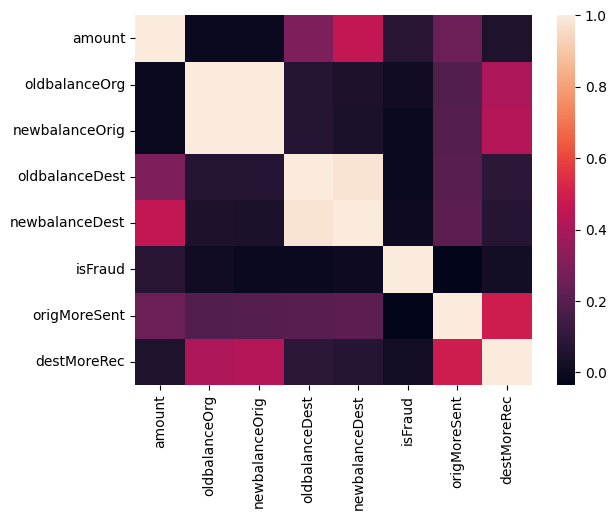

amount            0.076688
oldbalanceOrg     0.010154
newbalanceOrig   -0.008148
oldbalanceDest   -0.005885
newbalanceDest    0.000535
isFraud           1.000000
origMoreSent     -0.034843
destMoreRec       0.017692
Name: isFraud, dtype: float64


In [123]:
corrPlot = dfCorr.corr()
sns.heatmap(corrPlot)
plt.show()
print(corrPlot["isFraud"])